In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, multilabel_confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import timm
from transformers import ViTImageProcessor, ViTForImageClassification
import warnings
warnings.filterwarnings('ignore')
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit


# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [ ]:
# ============================================================================
# CONFIGURATION
# ============================================================================

BASE_DIR = "./dataset_balanced/"
CSV_PATH = os.path.join(BASE_DIR, "new_labels.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "new_images", "new_images")

# Disease labels for multi-label classification
DISEASE_LABELS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

TARGET_LABELS = ['Infiltration', 'Consolidation', 'Pneumonia', 'Mass', 'Nodule']

NUM_CLASSES = len(TARGET_LABELS)
print(f"Number of disease classes: {NUM_CLASSES}")
print(f"Disease labels: {DISEASE_LABELS}")

# Training hyperparameters
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
IMAGE_SIZE = 224

Number of disease classes: 5
Disease labels: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [3]:
# ============================================================================
# LOAD AND PREPARE DATA WITH TRAIN/VAL/TEST SPLIT
# ============================================================================

# Load dataset
df = pd.read_csv(CSV_PATH)

# Load ALL disease labels first (needed for filtering/stratification)
df_full = df[['Path'] + DISEASE_LABELS].copy()

# Select only TARGET labels for training
df = df_full[['Path'] + TARGET_LABELS].copy()

print(f"\nTotal samples: {len(df)}")
print(f"Dataset shape: {df.shape}")

# Create stratified split based on TARGET disease presence
df['disease_count'] = df[TARGET_LABELS].sum(axis=1)  # ← Changed to TARGET_LABELS
df['has_any_disease'] = (df['disease_count'] > 0).astype(int)

# First split: Train (70%) vs Temp (30%)
train_df, temp_df = train_test_split(
    df, 
    test_size=0.3,
    stratify=df['has_any_disease']
)

# Second split: Val (15%) vs Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['has_any_disease']
)

print(f"\nTraining samples: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation samples: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test samples: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

# Verify stratification
print(f"\nPositive rates (has any target disease):")
print(f"  Training: {train_df['has_any_disease'].mean():.3f}")
print(f"  Validation: {val_df['has_any_disease'].mean():.3f}")
print(f"  Test: {test_df['has_any_disease'].mean():.3f}")

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


Total samples: 51382
Dataset shape: (51382, 6)

Training samples: 35967 (70.0%)
Validation samples: 7707 (15.0%)
Test samples: 7708 (15.0%)

Positive rates (has any target disease):
  Training: 0.449
  Validation: 0.449
  Test: 0.450


In [4]:
# ============================================================================
# CALCULATE CLASS WEIGHTS FOR WEIGHTED BCE LOSS
# ============================================================================

def calculate_class_weights(dataframe, disease_labels, method='balanced'):
    """
    Calculate class weights for imbalanced dataset
    
    Args:
        dataframe: training dataframe
        disease_labels: list of disease labels
        method: 'balanced' or 'effective_samples'
    
    Returns:
        pos_weights: tensor of positive class weights for BCEWithLogitsLoss
    """
    pos_counts = []
    neg_counts = []
    
    for label in disease_labels:
        pos_count = dataframe[label].sum()
        neg_count = len(dataframe) - pos_count
        pos_counts.append(pos_count)
        neg_counts.append(neg_count)
    
    pos_counts = np.array(pos_counts)
    neg_counts = np.array(neg_counts)
    
    if method == 'balanced':
        # Weight = neg_samples / pos_samples
        # This makes positive class loss more important when rare
        pos_weights = neg_counts / (pos_counts + 1e-5)
    
    elif method == 'effective_samples':
        # Effective Number of Samples method (better for extremely imbalanced)
        beta = 0.9999
        effective_num_pos = 1.0 - np.power(beta, pos_counts)
        effective_num_neg = 1.0 - np.power(beta, neg_counts)
        pos_weights = effective_num_neg / (effective_num_pos + 1e-5)
    
    else:
        pos_weights = np.ones(len(disease_labels))
    
    print(f"\nClass weights (method: {method}):")
    for label, pos_w, pos_c, neg_c in zip(disease_labels, pos_weights, pos_counts, neg_counts):
        print(f"  {label:20s}: weight={pos_w:6.3f} (pos={pos_c:5d}, neg={neg_c:5d}, ratio={neg_c/pos_c:5.2f})")
    
    return torch.tensor(pos_weights, dtype=torch.float32)

# Calculate class weights from training data
pos_weights = calculate_class_weights(train_df, TARGET_LABELS, method='balanced')


Class weights (method: balanced):
  Infiltration        : weight= 8.067 (pos= 3967, neg=32000, ratio= 8.07)
  Consolidation       : weight=10.378 (pos= 3161, neg=32806, ratio=10.38)
  Pneumonia           : weight= 7.413 (pos= 4275, neg=31692, ratio= 7.41)
  Mass                : weight= 8.294 (pos= 3870, neg=32097, ratio= 8.29)
  Nodule              : weight= 8.110 (pos= 3948, neg=32019, ratio= 8.11)


In [5]:
# ============================================================================
# IMPORT CUSTOM DATASET CLASS
# ============================================================================
from dataset_handler import NIHChestXrayDataset

print("NIHChestXrayDataset class imported successfully.")

NIHChestXrayDataset class imported successfully.


In [6]:
# ============================================================================
# DATA AUGMENTATION AND TRANSFORMS (Conservative for CXR)
# ============================================================================

# Training transforms with MINIMAL augmentation (CXR-sensitive)
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),  # Safe for CXR
    transforms.RandomRotation(degrees=5),    # Reduced to ±5° (was 10°)
    # Removed ColorJitter - CXR intensity values are diagnostically important
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Validation transforms (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Test transforms (identical to validation)
test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

In [7]:
# ============================================================================
# CREATE DATASETS AND DATALOADERS
# ============================================================================

# Create datasets
train_dataset = NIHChestXrayDataset(
    train_df, IMAGE_DIR, TARGET_LABELS, transform=train_transforms
)
val_dataset = NIHChestXrayDataset(
    val_df, IMAGE_DIR, TARGET_LABELS, transform=val_transforms
)
test_dataset = NIHChestXrayDataset(
    test_df, IMAGE_DIR, TARGET_LABELS, transform=test_transforms  # Same as val
)

# Create data loaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=4,  # Set to 0 for Windows
    pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=4,
    pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,  # Never shuffle test data
    num_workers=4,
    pin_memory=torch.cuda.is_available()
)

print(f"\nNumber of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")


Number of training batches: 1124
Number of validation batches: 241
Number of test batches: 241


In [8]:
# ============================================================================
# MODEL DEFINITION
# ============================================================================

class ViTForMultiLabelClassification(nn.Module):
    """Vision Transformer for multi-label classification"""
    
    def __init__(self, num_classes, pretrained=True):
        super(ViTForMultiLabelClassification, self).__init__()
        
        # Load pretrained ViT model using timm
        self.vit = timm.create_model(
            'vit_base_patch16_224',
            pretrained=pretrained,
            num_classes=0  # Remove classification head
        )
        
        # Get the feature dimension
        self.feature_dim = self.vit.num_features
        
        # Custom classification head for multi-label
        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        # Extract features
        features = self.vit(x)
        
        # Classification
        logits = self.classifier(features)
        
        return logits

# Initialize model
model = ViTForMultiLabelClassification(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(device)

print(f"\nModel architecture:")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Model architecture:
Total parameters: 86,194,949
Trainable parameters: 86,194,949


In [9]:
# ============================================================================
# LOSS FUNCTION AND OPTIMIZER
# ============================================================================

# Binary Cross Entropy with Logits Loss (handles multi-label)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights.to(device))

# AdamW optimizer
optimizer = optim.AdamW(
    model.parameters(), 
    lr=LEARNING_RATE, 
    weight_decay=WEIGHT_DECAY
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=NUM_EPOCHS
)

In [10]:
# ============================================================================
# TRAINING AND EVALUATION FUNCTIONS
# ============================================================================

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(dataloader, desc='Training')
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * images.size(0)
        
        # Store predictions and labels
        preds = torch.sigmoid(outputs).detach().cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.cpu().numpy())
        
        pbar.set_postfix({'loss': loss.item()})
    
    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    return epoch_loss, all_preds, all_labels

def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation')
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * images.size(0)
            
            # Store predictions and labels
            preds = torch.sigmoid(outputs).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())
            
            pbar.set_postfix({'loss': loss.item()})
    
    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    return epoch_loss, all_preds, all_labels

def compute_metrics(labels, predictions, threshold=0.5):
    """Compute evaluation metrics"""
    metrics = {}
    
    # ROC AUC (per class and mean)
    try:
        auc_scores = []
        for i in range(labels.shape[1]):
            if len(np.unique(labels[:, i])) > 1:  # Check if both classes present
                auc = roc_auc_score(labels[:, i], predictions[:, i])
                auc_scores.append(auc)
        metrics['auc_mean'] = np.mean(auc_scores) if auc_scores else 0.0
    except:
        metrics['auc_mean'] = 0.0
    
    # Average Precision (per class and mean)
    try:
        ap_scores = []
        for i in range(labels.shape[1]):
            if len(np.unique(labels[:, i])) > 1:
                ap = average_precision_score(labels[:, i], predictions[:, i])
                ap_scores.append(ap)
        metrics['ap_mean'] = np.mean(ap_scores) if ap_scores else 0.0
    except:
        metrics['ap_mean'] = 0.0
    
    # Binary predictions for accuracy
    binary_preds = (predictions >= threshold).astype(int)
    
    # Accuracy
    metrics['accuracy'] = np.mean(binary_preds == labels)
    
    return metrics

In [11]:
# ============================================================================
# TRAINING LOOP
# ============================================================================

print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)

history = {
    'train_loss': [],
    'val_loss': [],
    'train_auc': [],
    'val_auc': [],
    'train_ap': [],
    'val_ap': [],
    'train_acc': [],
    'val_acc': []
}

best_val_auc = 0.0
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 70)
    
    # Train
    train_loss, train_preds, train_labels = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    train_metrics = compute_metrics(train_labels, train_preds)
    
    # Validate
    val_loss, val_preds, val_labels = validate_epoch(
        model, val_loader, criterion, device
    )
    val_metrics = compute_metrics(val_labels, val_preds)
    
    # Update learning rate
    scheduler.step()
    
    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_metrics['auc_mean'])
    history['val_auc'].append(val_metrics['auc_mean'])
    history['train_ap'].append(train_metrics['ap_mean'])
    history['val_ap'].append(val_metrics['ap_mean'])
    history['train_acc'].append(train_metrics['accuracy'])
    history['val_acc'].append(val_metrics['accuracy'])
    
    # Print metrics
    print(f"\nTrain Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Train AUC: {train_metrics['auc_mean']:.4f} | Val AUC: {val_metrics['auc_mean']:.4f}")
    print(f"Train AP: {train_metrics['ap_mean']:.4f} | Val AP: {val_metrics['ap_mean']:.4f}")
    print(f"Train Acc: {train_metrics['accuracy']:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")
    
    # Save best model
    if val_metrics['auc_mean'] > best_val_auc:
        best_val_auc = val_metrics['auc_mean']
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_auc': best_val_auc,
        }, 'best_vit_model.pth')
        print(f"✓ Saved best model (Val AUC: {best_val_auc:.4f})")

print(f"\n{'='*70}")
print(f"TRAINING COMPLETED")
print(f"Best Val AUC: {best_val_auc:.4f} at epoch {best_epoch}")
print(f"{'='*70}")


STARTING TRAINING

Epoch 1/10
----------------------------------------------------------------------


Validation: 100%|██████████| 241/241 [01:33<00:00,  2.57it/s, loss=0.964]



Train Loss: 1.1170 | Val Loss: 1.0694
Train AUC: 0.6930 | Val AUC: 0.7537
Train AP: 0.2444 | Val AP: 0.3215
Train Acc: 0.6414 | Val Acc: 0.6096
✓ Saved best model (Val AUC: 0.7537)

Epoch 2/10
----------------------------------------------------------------------


Validation: 100%|██████████| 241/241 [01:31<00:00,  2.62it/s, loss=1.03] 



Train Loss: 0.9996 | Val Loss: 0.9893
Train AUC: 0.7721 | Val AUC: 0.7956
Train AP: 0.3430 | Val AP: 0.3959
Train Acc: 0.7041 | Val Acc: 0.7105
✓ Saved best model (Val AUC: 0.7956)

Epoch 3/10
----------------------------------------------------------------------


...


Train Loss: 0.4864 | Val Loss: 1.0540
Train AUC: 0.9465 | Val AUC: 0.8509
Train AP: 0.7516 | Val AP: 0.5668
Train Acc: 0.8661 | Val Acc: 0.8434
✓ Saved best model (Val AUC: 0.8509)

Epoch 8/10
----------------------------------------------------------------------


Validation: 100%|██████████| 241/241 [02:42<00:00,  1.48it/s, loss=0.672]



Train Loss: 0.3931 | Val Loss: 1.0016
Train AUC: 0.9643 | Val AUC: 0.8572
Train AP: 0.8135 | Val AP: 0.5745
Train Acc: 0.8941 | Val Acc: 0.8284
✓ Saved best model (Val AUC: 0.8572)

Epoch 9/10
----------------------------------------------------------------------


Training:   0%|          | 0/1124 [00:08<?, ?it/s]


KeyboardInterrupt: 

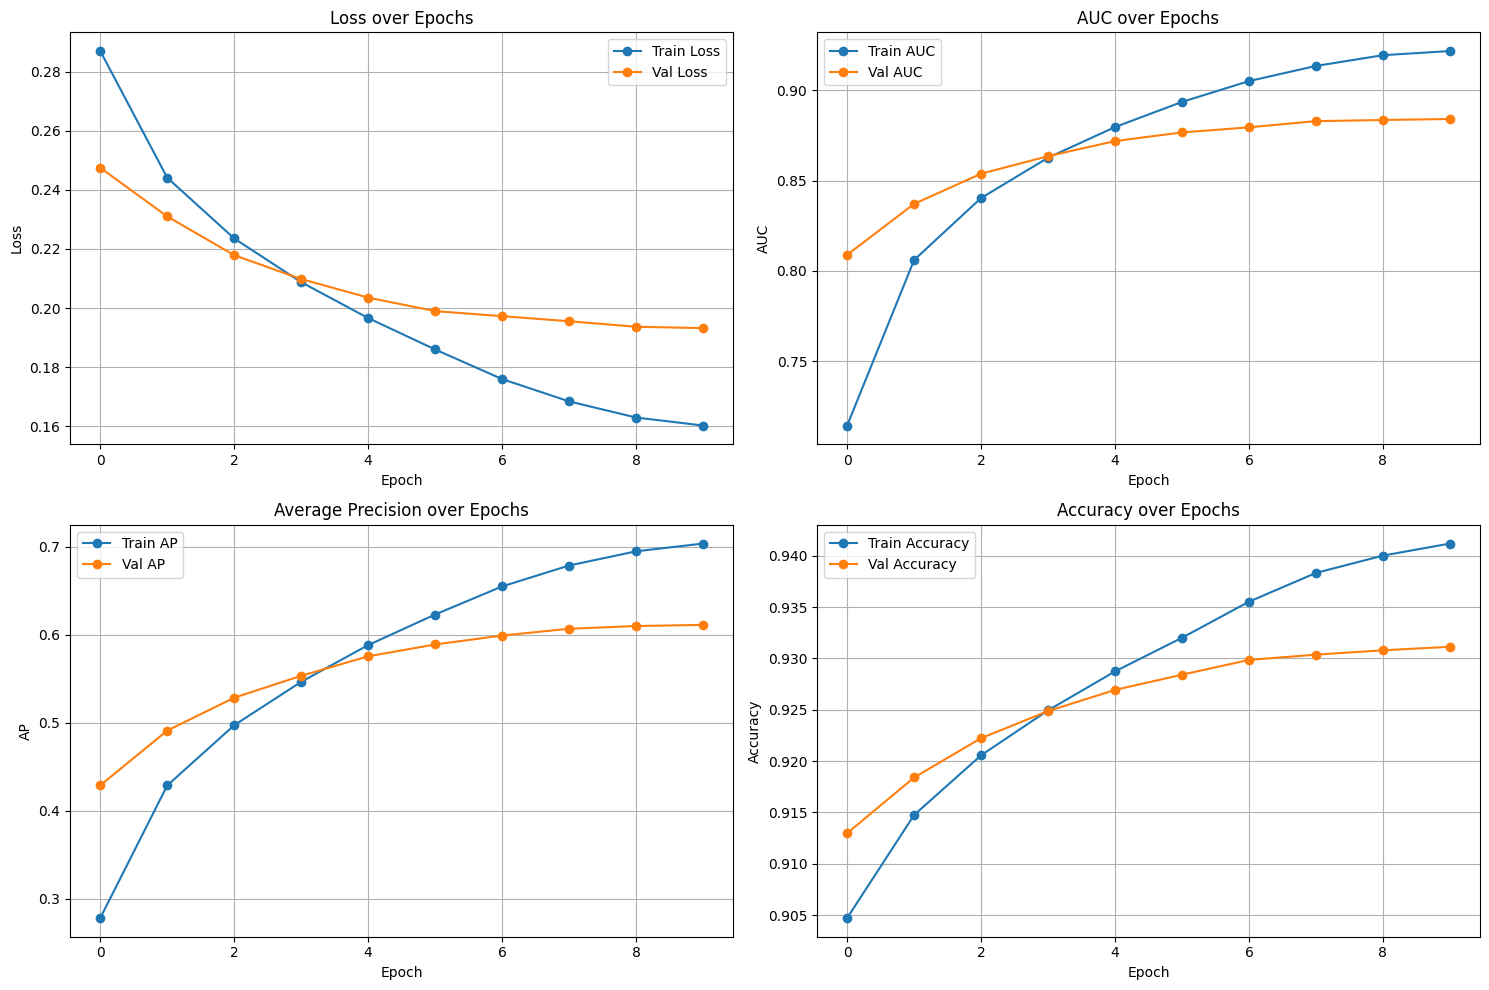


✓ Training history plot saved as 'training_history.png'


In [ ]:
# ============================================================================
# PLOT TRAINING HISTORY
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0, 0].set_title('Loss over Epochs')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# AUC
axes[0, 1].plot(history['train_auc'], label='Train AUC', marker='o')
axes[0, 1].plot(history['val_auc'], label='Val AUC', marker='o')
axes[0, 1].set_title('AUC over Epochs')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Average Precision
axes[1, 0].plot(history['train_ap'], label='Train AP', marker='o')
axes[1, 0].plot(history['val_ap'], label='Val AP', marker='o')
axes[1, 0].set_title('Average Precision over Epochs')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AP')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Accuracy
axes[1, 1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[1, 1].plot(history['val_acc'], label='Val Accuracy', marker='o')
axes[1, 1].set_title('Accuracy over Epochs')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Training history plot saved as 'training_history.png'")

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

# ============================================================================
# EVALUATE ON VALIDATION SET WITH BEST MODEL
# ============================================================================

print("\n" + "="*70)
print("FINAL EVALUATION ON BEST MODEL")
print("="*70)

# Load best model
checkpoint = torch.load('best_vit_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")

# Evaluate
val_loss, val_preds, val_labels = validate_epoch(model, val_loader, criterion, device)
val_metrics = compute_metrics(val_labels, val_preds)

# Convert predictions to binary (threshold = 0.5)
val_preds_binary = (val_preds >= 0.5).astype(int)

print(f"\nOverall Metrics:")
print("-" * 70)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation AUC: {val_metrics['auc_mean']:.4f}")
print(f"Validation AP: {val_metrics['ap_mean']:.4f}")
print(f"Validation Accuracy: {val_metrics['accuracy']:.4f}")

# F1 Scores
f1_micro = f1_score(val_labels, val_preds_binary, average='micro')
f1_macro = f1_score(val_labels, val_preds_binary, average='macro')
f1_weighted = f1_score(val_labels, val_preds_binary, average='weighted')

print(f"\nF1 Scores:")
print(f"  F1 (Micro):    {f1_micro:.4f}")
print(f"  F1 (Macro):    {f1_macro:.4f}")
print(f"  F1 (Weighted): {f1_weighted:.4f}")

# Precision and Recall
precision_micro = precision_score(val_labels, val_preds_binary, average='micro')
precision_macro = precision_score(val_labels, val_preds_binary, average='macro')
recall_micro = recall_score(val_labels, val_preds_binary, average='micro')
recall_macro = recall_score(val_labels, val_preds_binary, average='macro')

print(f"\nPrecision & Recall:")
print(f"  Precision (Micro): {precision_micro:.4f}")
print(f"  Precision (Macro): {precision_macro:.4f}")
print(f"  Recall (Micro):    {recall_micro:.4f}")
print(f"  Recall (Macro):    {recall_macro:.4f}")

# Per-class metrics
print(f"\n{'='*70}")
print("PER-CLASS METRICS")
print("="*70)
print(f"{'Disease':<25} {'AUC':<8} {'AP':<8} {'F1':<8} {'Prec':<8} {'Recall':<8}")
print("-" * 70)

for i, label in enumerate(TARGET_LABELS):
    if len(np.unique(val_labels[:, i])) > 1:
        auc = roc_auc_score(val_labels[:, i], val_preds[:, i])
        ap = average_precision_score(val_labels[:, i], val_preds[:, i])
        f1 = f1_score(val_labels[:, i], val_preds_binary[:, i], zero_division=0)
        precision = precision_score(val_labels[:, i], val_preds_binary[:, i], zero_division=0)
        recall = recall_score(val_labels[:, i], val_preds_binary[:, i], zero_division=0)
        
        print(f"{label:<25} {auc:<8.4f} {ap:<8.4f} {f1:<8.4f} {precision:<8.4f} {recall:<8.4f}")
    else:
        print(f"{label:<25} {'N/A':<8} {'N/A':<8} {'N/A':<8} {'N/A':<8} {'N/A':<8}")

print("\n" + "="*70)
print("✓ Training and evaluation complete!")
print("="*70)


FINAL EVALUATION ON BEST MODEL
Loaded best model from epoch 10


Validation: 100%|██████████| 322/322 [01:57<00:00,  2.74it/s, loss=0.151]



Overall Metrics:
----------------------------------------------------------------------
Validation Loss: 0.1932
Validation AUC: 0.8841
Validation AP: 0.6113
Validation Accuracy: 0.9311

F1 Scores:
  F1 (Micro):    0.5557
  F1 (Macro):    0.5159
  F1 (Weighted): 0.5154

Precision & Recall:
  Precision (Micro): 0.7753
  Precision (Macro): 0.7322
  Recall (Micro):    0.4331
  Recall (Macro):    0.4329

PER-CLASS METRICS
Disease                   AUC      AP       F1       Prec     Recall  
----------------------------------------------------------------------
Atelectasis               0.8151   0.3974   0.2862   0.6113   0.1868  
Cardiomegaly              0.9586   0.8002   0.7252   0.8030   0.6612  
Consolidation             0.8178   0.3824   0.2474   0.5917   0.1564  
Edema                     0.9543   0.8038   0.7411   0.8072   0.6851  
Effusion                  0.8607   0.5456   0.4420   0.6879   0.3256  
Emphysema                 0.9390   0.7358   0.6684   0.7877   0.5805  
Fibrosis  

In [ ]:
# ============================================================================
# FINAL TEST SET EVALUATION
# ============================================================================

print("\n" + "="*70)
print("FINAL TEST SET EVALUATION (UNSEEN DATA)")
print("="*70)

# Load best model
checkpoint = torch.load('best_vit_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")

# Evaluate on TEST set (not validation!)
test_loss, test_preds, test_labels = validate_epoch(model, test_loader, criterion, device)
test_metrics = compute_metrics(test_labels, test_preds)

# Convert to binary
test_preds_binary = (test_preds >= 0.5).astype(int)

print(f"\nTest Set Metrics:")
print("-" * 70)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test AUC: {test_metrics['auc_mean']:.4f}")
print(f"Test AP: {test_metrics['ap_mean']:.4f}")
print(f"Test Accuracy: {test_metrics['accuracy']:.4f}")

# F1 Scores
f1_micro = f1_score(test_labels, test_preds_binary, average='micro')
f1_macro = f1_score(test_labels, test_preds_binary, average='macro')

print(f"\nTest F1 Scores:")
print(f"  F1 (Micro): {f1_micro:.4f}")
print(f"  F1 (Macro): {f1_macro:.4f}")

# Per-class metrics
print(f"\nPer-class Test Metrics:")
print(f"{'Disease':<25} {'AUC':<8} {'AP':<8} {'F1':<8}")
print("-" * 70)
for i, label in enumerate(TARGET_LABELS):
    if len(np.unique(test_labels[:, i])) > 1:
        auc = roc_auc_score(test_labels[:, i], test_preds[:, i])
        ap = average_precision_score(test_labels[:, i], test_preds[:, i])
        f1 = f1_score(test_labels[:, i], test_preds_binary[:, i], zero_division=0)
        print(f"{label:<25} {auc:<8.4f} {ap:<8.4f} {f1:<8.4f}")